# Day 6: Continuous Probability Distributions — Comprehensive Master Lab
### Course: Data Analytics (CDAC PGCP-AI)

This notebook provides a rigorous, practical, and visual exploration of **all major continuous probability distributions** used in Data Analytics, Inferential Statistics, and Machine Learning.

**Taxonomy of Distributions Covered:**
1. **Fundamental Symmetric & Baseline:** Normal (Gaussian), Standard Normal $\mathcal{Z}$, Continuous Uniform
2. **Skewed, Lifetime & Waiting Times:** Exponential, Gamma, Weibull, Log-Normal, Pareto (Power-Law)
3. **Inferential & Hypothesis Testing:** Student's t, Chi-Square ($\chi^2$), F-Distribution (ANOVA)
4. **Bounded Interval Modeling:** Beta Distribution ($x \in [0, 1]$), Triangular Distribution (PERT/Risk)
5. **Heavy-Tailed & Specialized:** Laplace (Double Exponential / L1 Lasso), Cauchy (Lorentzian), Logistic
6. **Statistical Model Selection & Goodness-of-Fit:** Maximum Likelihood Fitting & Kolmogorov-Smirnov (K-S) Testing

---


In [1]:
# ==============================================================================
# STEP 0: ENVIRONMENT SETUP & MODERN NUMPY RANDOM GENERATOR API
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

# Modern NumPy Generator API for reproducible sampling
rng = np.random.default_rng(seed=42)

print("Environment initialized successfully for Day 6 Continuous Probability Distributions!")
print(f"NumPy Version : {np.__version__}")
print(f"SciPy Version : {stats.__file__.split('site-packages')[0] if hasattr(stats, '__file__') else 'Loaded'}")


Environment initialized successfully for Day 6 Continuous Probability Distributions!
NumPy Version : 2.4.6
SciPy Version : C:\Users\conne\AppData\Roaming\Python\Python313\


## 1. Fundamental Symmetric & Baseline Distributions

### 1.1 The Normal (Gaussian) Distribution: $\mathcal{N}(\mu, \sigma^2)$
The cornerstone of classical statistics. By the **Central Limit Theorem (CLT)**, the sum or mean of a large number of independent random variables converges to a Gaussian distribution, regardless of their original underlying distribution.

**Probability Density Function (PDF):**
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left( -\frac{(x - \mu)^2}{2\sigma^2} \right), \quad x \in (-\infty, \infty)$$

- **Parameters:** Mean $\mu \in \mathbb{R}$ (location of peak), Standard Deviation $\sigma > 0$ (dispersion/width).
- **Moments:** $\mathbb{E}[X] = \mu, \quad \text{Var}(X) = \sigma^2, \quad \text{Skewness} = 0, \quad \text{Excess Kurtosis} = 0$.
- **The Empirical 68-95-99.7 Rule:**
  - $P(\mu - 1\sigma \le X \le \mu + 1\sigma) \approx 68.27\%$
  - $P(\mu - 2\sigma \le X \le \mu + 2\sigma) \approx 95.45\%$
  - $P(\mu - 3\sigma \le X \le \mu + 3\sigma) \approx 99.73\%$

### 1.2 The Continuous Uniform Distribution: $\mathcal{U}(a, b)$
Assigns equal probability density across every point in the closed interval $[a, b]$. Represents complete uncertainty (maximum entropy) over a bounded range.

**PDF & Moments:**
$$f(x) = \frac{1}{b - a} \quad \text{for } a \le x \le b, \quad \mathbb{E}[X] = \frac{a + b}{2}, \quad \text{Var}(X) = \frac{(b - a)^2}{12}$$


           NORMAL DISTRIBUTION: EMPIRICAL 68-95-99.7 RULE VERIFICATION         
Theoretical 1-sigma [48, 52] mm : 68.27% | Sample Empirical: 67.85%
Theoretical 2-sigma [46, 54] mm : 95.45% | Sample Empirical: 95.41%
Theoretical 3-sigma [44, 56] mm : 99.73% | Sample Empirical: 99.67%
Empirical Mean: 49.9795 (True: 50.0) | Std: 2.0127 (True: 2.0)


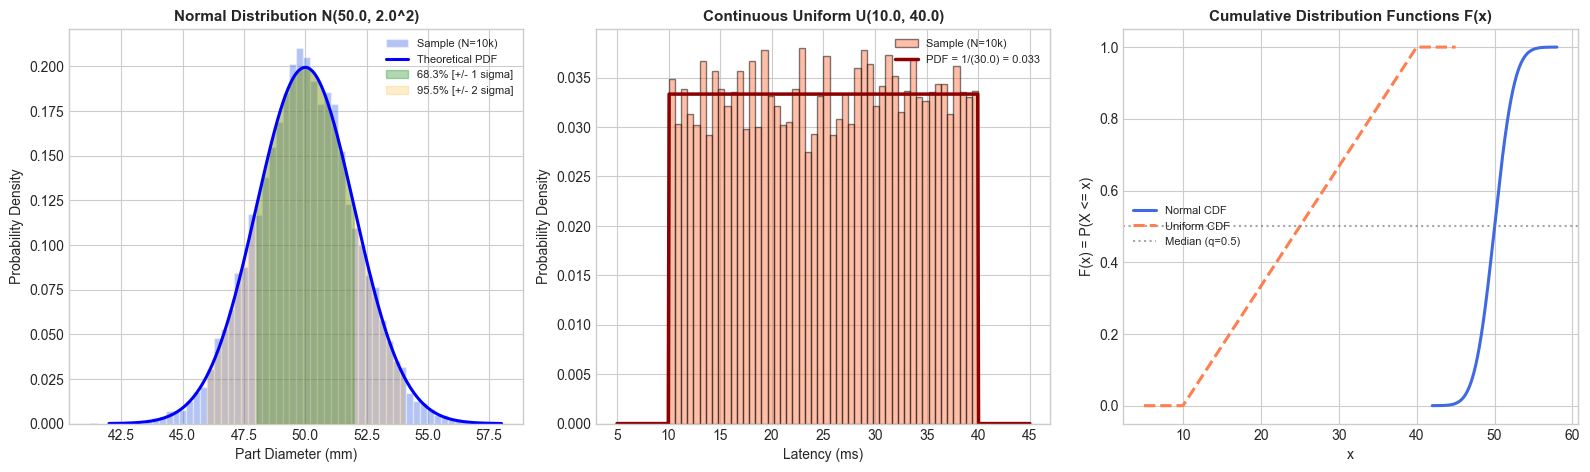

In [3]:
# ==============================================================================
# SECTION 1 CODE: GAUSSIAN EMPIRICAL RULE & CONTINUOUS UNIFORM
# ==============================================================================
# 1. Normal Distribution Simulation: Factory Part Diameters (mu=50mm, sigma=2mm)
mu_norm, sigma_norm = 50.0, 2.0
N_samples = 10000
sample_normal = rng.normal(loc=mu_norm, scale=sigma_norm, size=N_samples)

# 2. Uniform Distribution Simulation: Processing Latency (a=10ms, b=40ms)
a_uni, b_uni = 10.0, 40.0
sample_uniform = rng.uniform(low=a_uni, high=b_uni, size=N_samples)

# 3. Empirical Verification of the 68-95-99.7 Rule
within_1s = np.mean((sample_normal >= mu_norm - 1*sigma_norm) & (sample_normal <= mu_norm + 1*sigma_norm))
within_2s = np.mean((sample_normal >= mu_norm - 2*sigma_norm) & (sample_normal <= mu_norm + 2*sigma_norm))
within_3s = np.mean((sample_normal >= mu_norm - 3*sigma_norm) & (sample_normal <= mu_norm + 3*sigma_norm))

print("=" * 75)
print("           NORMAL DISTRIBUTION: EMPIRICAL 68-95-99.7 RULE VERIFICATION         ")
print("=" * 75)
print(f"Theoretical 1-sigma [48, 52] mm : 68.27% | Sample Empirical: {within_1s*100:.2f}%")
print(f"Theoretical 2-sigma [46, 54] mm : 95.45% | Sample Empirical: {within_2s*100:.2f}%")
print(f"Theoretical 3-sigma [44, 56] mm : 99.73% | Sample Empirical: {within_3s*100:.2f}%")
print(f"Empirical Mean: {np.mean(sample_normal):.4f} (True: {mu_norm}) | Std: {np.std(sample_normal, ddof=1):.4f} (True: {sigma_norm})")
print("=" * 75)

# 4. Visualizations: Normal vs. Uniform
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Plot 1: Normal Distribution with Shaded Sigma Regions
x_norm_grid = np.linspace(mu_norm - 4*sigma_norm, mu_norm + 4*sigma_norm, 500)
pdf_norm = stats.norm.pdf(x_norm_grid, mu_norm, sigma_norm)
axes[0].hist(sample_normal, bins=60, density=True, alpha=0.4, color='royalblue', edgecolor='white', label='Sample (N=10k)')
axes[0].plot(x_norm_grid, pdf_norm, 'b-', lw=2.2, label='Theoretical PDF')
# Shading sigma bounds
axes[0].fill_between(x_norm_grid, pdf_norm, where=(x_norm_grid >= mu_norm - sigma_norm) & (x_norm_grid <= mu_norm + sigma_norm),
                     color='green', alpha=0.3, label='68.3% [+/- 1 sigma]')
axes[0].fill_between(x_norm_grid, pdf_norm, where=(x_norm_grid >= mu_norm - 2*sigma_norm) & (x_norm_grid <= mu_norm + 2*sigma_norm),
                     color='orange', alpha=0.2, label='95.5% [+/- 2 sigma]')
axes[0].set_title(f'Normal Distribution N({mu_norm}, {sigma_norm}^2)', fontweight='bold')
axes[0].set_xlabel('Part Diameter (mm)'); axes[0].set_ylabel('Probability Density')
axes[0].legend(fontsize=8, loc='upper right')

# Plot 2: Uniform Distribution
x_uni_grid = np.linspace(a_uni - 5, b_uni + 5, 500)
pdf_uni = stats.uniform.pdf(x_uni_grid, loc=a_uni, scale=b_uni - a_uni)
axes[1].hist(sample_uniform, bins=50, density=True, alpha=0.5, color='coral', edgecolor='black', label='Sample (N=10k)')
axes[1].plot(x_uni_grid, pdf_uni, color='darkred', lw=2.5, label=f'PDF = 1/({b_uni-a_uni}) = {1/(b_uni-a_uni):.3f}')
axes[1].set_title(f'Continuous Uniform U({a_uni}, {b_uni})', fontweight='bold')
axes[1].set_xlabel('Latency (ms)'); axes[1].set_ylabel('Probability Density')
axes[1].legend(fontsize=8, loc='upper right')

# Plot 3: Cumulative Distribution Functions (CDFs)
cdf_norm = stats.norm.cdf(x_norm_grid, mu_norm, sigma_norm)
cdf_uni = stats.uniform.cdf(x_uni_grid, loc=a_uni, scale=b_uni - a_uni)
axes[2].plot(x_norm_grid, cdf_norm, color='royalblue', lw=2.2, label='Normal CDF')
axes[2].plot(x_uni_grid, cdf_uni, color='coral', lw=2.2, linestyle='--', label='Uniform CDF')
axes[2].axhline(0.5, color='gray', linestyle=':', alpha=0.7, label='Median (q=0.5)')
axes[2].set_title('Cumulative Distribution Functions F(x)', fontweight='bold')
axes[2].set_xlabel('x'); axes[2].set_ylabel('F(x) = P(X <= x)')
axes[2].legend(fontsize=8, loc='center left')

plt.tight_layout()
plt.show()


## 2. Skewed, Lifetime & Waiting-Time Distributions (Non-Negative Support $[0, \infty)$)

In engineering, finance, and operational analytics, values cannot be negative, and distributions frequently exhibit positive skew (long right tails).

### 2.1 Exponential Distribution: $\text{Exp}(\lambda)$
- Models the **time elapsed between independent Poisson event arrivals** (e.g., website user hits, hardware failures).
- **Memoryless Property:** $P(X > s + t \mid X > s) = P(X > t)$. The component does not "wear out" over time; past survival conveys no information about future lifespan.
- **PDF & Moments:** $f(x) = \lambda e^{-\lambda x}, \quad \mathbb{E}[X] = \frac{1}{\lambda}, \quad \text{Var}(X) = \frac{1}{\lambda^2}$.

### 2.2 Gamma Distribution: $\text{Gamma}(k, \theta)$
- Represents the **sum of $k$ independent exponential variables** with scale $\theta = 1/\lambda$.
- Models aggregated customer service queues, multi-stage manufacturing workflows, and Bayesian conjugate priors for Poisson rates.
- **PDF:** $f(x) = \frac{x^{k-1} e^{-x/\theta}}{\theta^k \Gamma(k)}, \quad \mathbb{E}[X] = k\theta, \quad \text{Var}(X) = k\theta^2$.

### 2.3 Weibull Distribution: $\text{Weibull}(k, \lambda)$
- The gold standard for **Industrial Reliability & Survival Analysis**.
- Governed by the **Shape Parameter $k$**:
  - $k < 1$: **Decreasing failure rate** ("Infant mortality" / early defective parts weeded out).
  - $k = 1$: **Constant failure rate** (collapses exactly to the **Exponential** distribution).
  - $k > 1$: **Increasing failure rate** (wear-out, fatigue, mechanical aging; at $k \approx 3.6$, resembles a Gaussian).

### 2.4 Log-Normal Distribution: $\text{Lognormal}(\mu, \sigma)$
- If $Y = \ln(X) \sim \mathcal{N}(\mu, \sigma^2)$, then $X$ is Log-Normally distributed.
- Arises from **multiplicative processes** (Gibrat's Law): asset prices, stock returns, household income, internet file downloads.

### 2.5 Pareto Distribution: $\text{Pareto}(\alpha, x_m)$
- Models **Power-Law phenomena** and the **80/20 Rule** ($f(x) \propto x^{-(\alpha+1)}$).
- Characterized by extreme, heavy right tails where a tiny percentage of events account for the overwhelming majority of total magnitude.


         SKEWED DISTRIBUTIONS: THEORETICAL MOMENTS & CHARACTERISTICS          
                 Distribution  Mean  Variance Skewness Excess Kurtosis
      Exponential (scale=2.0) 2.000     4.000      2.0             6.0
     Gamma (k=2.5, theta=1.2) 3.000     3.600    1.265             2.4
   Weibull (k=2.0, scale=3.0) 2.659     1.931    0.631           0.245
Log-Normal (mu=0.8, sig=0.75) 2.948     6.570    2.871          17.652
   Pareto (alpha=2.5, xm=1.0) 1.667     5.556     High       Undefined


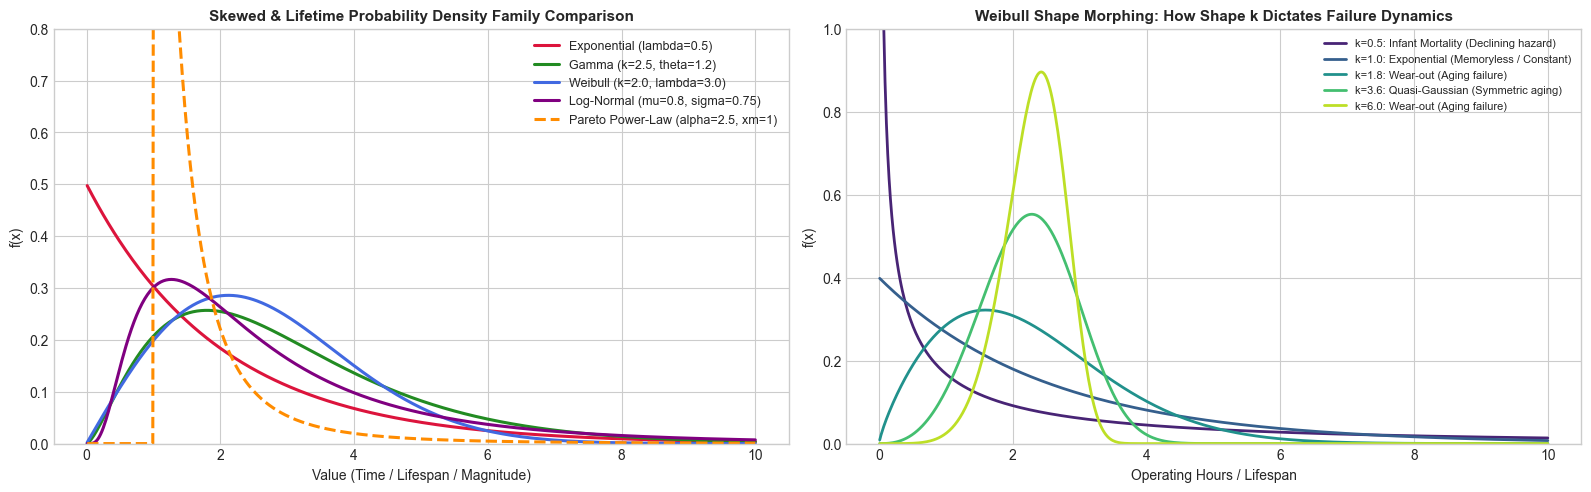

In [5]:
# ==============================================================================
# SECTION 2 CODE: SKEWED & LIFETIME FAMILY VISUALIZATION
# ==============================================================================
x_eval = np.linspace(0.01, 10.0, 500)

# 1. Compute Analytical PDFs across all 5 Skewed Distributions
pdf_expon = stats.expon.pdf(x_eval, scale=2.0)                 # lambda = 0.5, mean = 2.0
pdf_gamma = stats.gamma.pdf(x_eval, a=2.5, scale=1.2)          # k=2.5, theta=1.2
pdf_weibull_aging = stats.weibull_min.pdf(x_eval, c=2.0, scale=3.0) # k=2.0 (aging wear-out)
pdf_lognorm = stats.lognorm.pdf(x_eval, s=0.75, scale=np.exp(0.8))   # sigma=0.75, mu=0.8
pdf_pareto = stats.pareto.pdf(x_eval, b=2.5, scale=1.0)        # alpha=2.5, xm=1.0

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Cross-Family Comparison of Density Curves
axes[0].plot(x_eval, pdf_expon, color='crimson', lw=2.2, label='Exponential (lambda=0.5)')
axes[0].plot(x_eval, pdf_gamma, color='forestgreen', lw=2.2, label='Gamma (k=2.5, theta=1.2)')
axes[0].plot(x_eval, pdf_weibull_aging, color='royalblue', lw=2.2, label='Weibull (k=2.0, lambda=3.0)')
axes[0].plot(x_eval, pdf_lognorm, color='purple', lw=2.2, label='Log-Normal (mu=0.8, sigma=0.75)')
axes[0].plot(x_eval, pdf_pareto, color='darkorange', lw=2.2, linestyle='--', label='Pareto Power-Law (alpha=2.5, xm=1)')
axes[0].set_ylim(0, 0.8)
axes[0].set_title('Skewed & Lifetime Probability Density Family Comparison', fontweight='bold')
axes[0].set_xlabel('Value (Time / Lifespan / Magnitude)'); axes[0].set_ylabel('f(x)')
axes[0].legend(fontsize=9, loc='upper right')

# Subplot 2: Weibull Shape Morphing (Infant Mortality vs. Exponential vs. Aging)
k_values = [0.5, 1.0, 1.8, 3.6, 6.0]
colors_k = plt.cm.viridis(np.linspace(0.1, 0.9, len(k_values)))
for k_val, col in zip(k_values, colors_k):
    pdf_w = stats.weibull_min.pdf(x_eval, c=k_val, scale=2.5)
    lbl = f'k={k_val}: '
    if k_val < 1: lbl += 'Infant Mortality (Declining hazard)'
    elif k_val == 1: lbl += 'Exponential (Memoryless / Constant)'
    elif np.isclose(k_val, 3.6): lbl += 'Quasi-Gaussian (Symmetric aging)'
    else: lbl += 'Wear-out (Aging failure)'
    axes[1].plot(x_eval, pdf_w, color=col, lw=2.0, label=lbl)
axes[1].set_ylim(0, 1.0)
axes[1].set_title('Weibull Shape Morphing: How Shape k Dictates Failure Dynamics', fontweight='bold')
axes[1].set_xlabel('Operating Hours / Lifespan'); axes[1].set_ylabel('f(x)')
axes[1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

# Print Comparison Table
print("=" * 85)
print("         SKEWED DISTRIBUTIONS: THEORETICAL MOMENTS & CHARACTERISTICS          ")
print("=" * 85)
skew_summary = pd.DataFrame([
    {'Distribution': 'Exponential (scale=2.0)', 'Mean': 2.000, 'Variance': 4.000, 'Skewness': 2.000, 'Excess Kurtosis': 6.000},
    {'Distribution': 'Gamma (k=2.5, theta=1.2)', 'Mean': 3.000, 'Variance': 3.600, 'Skewness': 1.265, 'Excess Kurtosis': 2.400},
    {'Distribution': 'Weibull (k=2.0, scale=3.0)', 'Mean': 2.659, 'Variance': 1.931, 'Skewness': 0.631, 'Excess Kurtosis': 0.245},
    {'Distribution': 'Log-Normal (mu=0.8, sig=0.75)', 'Mean': 2.948, 'Variance': 6.570, 'Skewness': 2.871, 'Excess Kurtosis': 17.652},
    {'Distribution': 'Pareto (alpha=2.5, xm=1.0)', 'Mean': 1.667, 'Variance': 5.556, 'Skewness': 'High', 'Excess Kurtosis': 'Undefined'}
])
print(skew_summary.to_string(index=False))
print("=" * 85)


## 3. Inferential & Hypothesis Testing Distributions

These three continuous distributions are the mathematical backbone of **Hypothesis Testing, Confidence Interval Construction, and Linear Model Diagnostics**.

### 3.1 Student's t-Distribution: $t(\nu)$
- **The Problem it Solves:** When estimating a population mean $\mu$ from a small sample size ($n < 30$), the true population variance $\sigma^2$ is unknown and must be estimated via sample variance $s^2$. The resulting statistic does *not* follow a Normal distribution, but a Student's t-distribution with $\nu = n - 1$ degrees of freedom.
- **Characteristics:** Symmetric around 0 like the Gaussian, but has **heavier tails**. This wider spread reflects the increased uncertainty of small samples.
- **Asymptotic Convergence:** As $\nu \to \infty$, $t(\nu) \to \mathcal{N}(0, 1)$ by the Central Limit Theorem.

### 3.2 Chi-Square Distribution: $\chi^2(k)$
- **Definition:** The sum of $k$ independent squared standard normal variables:
  $$Q = \sum_{i=1}^k Z_i^2 \sim \chi^2(k), \quad \text{where } Z_i \sim \mathcal{N}(0, 1)$$
- **Primary Uses:** Testing sample variance ($H_0: \sigma^2 = \sigma_0^2$), Goodness-of-Fit tests, and Categorical Independence Contingency Tables (`scipy.stats.chi2_contingency`).
- **Moments:** $\mathbb{E}[X] = k, \quad \text{Var}(X) = 2k$.

### 3.3 Fisher-Snedecor F-Distribution: $F(d_1, d_2)$
- **Definition:** The ratio of two independent Chi-Square variables, each scaled by their respective degrees of freedom:
  $$F = \frac{\chi_1^2 / d_1}{\chi_2^2 / d_2} \sim F(d_1, d_2)$$
- **Primary Uses:** **ANOVA (Analysis of Variance)** across multiple group means, and testing the overall statistical significance of Multiple Linear Regression models ($R^2 > 0$).


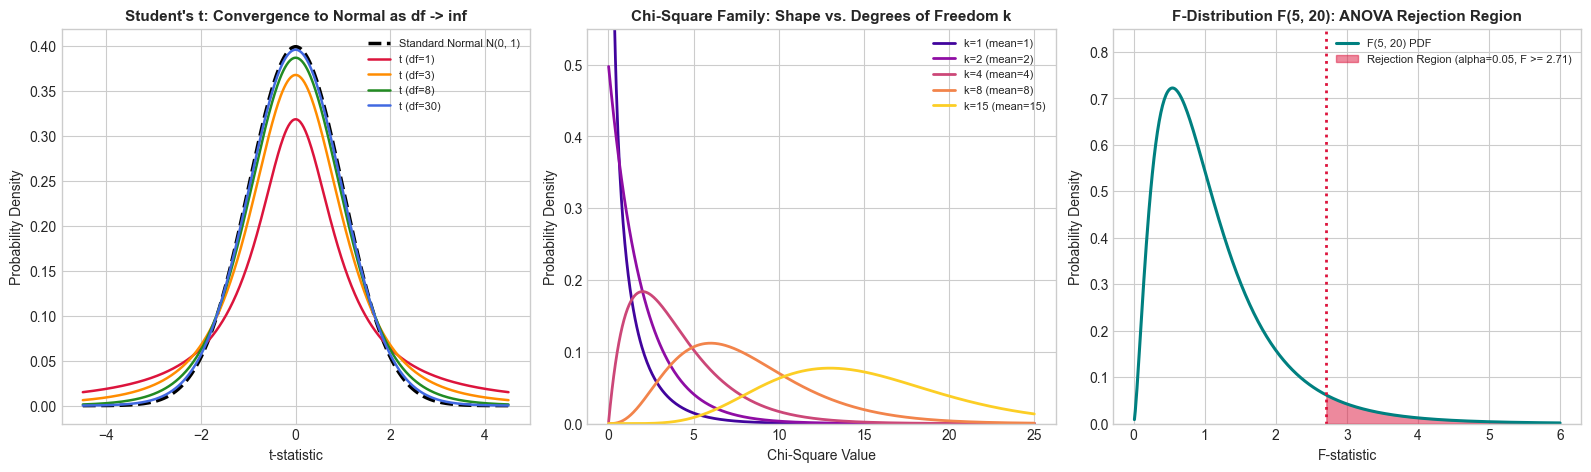

In [7]:
# ==============================================================================
# SECTION 3 CODE: INFERENTIAL SAMPLING DISTRIBUTIONS (T, CHI-SQUARE, F)
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Subplot 1: Student's t Convergence to Standard Normal
x_t = np.linspace(-4.5, 4.5, 500)
axes[0].plot(x_t, stats.norm.pdf(x_t), color='black', lw=2.5, linestyle='--', label='Standard Normal N(0, 1)')
for nu_val, col in zip([1, 3, 8, 30], ['crimson', 'darkorange', 'forestgreen', 'royalblue']):
    pdf_t = stats.t.pdf(x_t, df=nu_val)
    axes[0].plot(x_t, pdf_t, color=col, lw=1.8, label=f't (df={nu_val})')
axes[0].set_title("Student's t: Convergence to Normal as df -> inf", fontweight='bold')
axes[0].set_xlabel('t-statistic'); axes[0].set_ylabel('Probability Density')
axes[0].legend(fontsize=8, loc='upper right')

# Subplot 2: Chi-Square Distribution across Degrees of Freedom
x_chi = np.linspace(0.01, 25.0, 500)
for k_val, col in zip([1, 2, 4, 8, 15], plt.cm.plasma(np.linspace(0.1, 0.9, 5))):
    axes[1].plot(x_chi, stats.chi2.pdf(x_chi, df=k_val), color=col, lw=2.0, label=f'k={k_val} (mean={k_val})')
axes[1].set_ylim(0, 0.55)
axes[1].set_title('Chi-Square Family: Shape vs. Degrees of Freedom k', fontweight='bold')
axes[1].set_xlabel('Chi-Square Value'); axes[1].set_ylabel('Probability Density')
axes[1].legend(fontsize=8, loc='upper right')

# Subplot 3: F-Distribution and Critical Rejection Region (alpha = 0.05)
x_f = np.linspace(0.01, 6.0, 500)
d1, d2 = 5, 20
pdf_f = stats.f.pdf(x_f, dfn=d1, dfd=d2)
crit_val = stats.f.ppf(0.95, dfn=d1, dfd=d2)  # Critical threshold for alpha = 0.05
axes[2].plot(x_f, pdf_f, color='teal', lw=2.2, label=f'F({d1}, {d2}) PDF')
axes[2].fill_between(x_f, pdf_f, where=(x_f >= crit_val), color='crimson', alpha=0.5,
                     label=f'Rejection Region (alpha=0.05, F >= {crit_val:.2f})')
axes[2].axvline(crit_val, color='crimson', linestyle=':', lw=2.0)
axes[2].set_ylim(0, 0.85)
axes[2].set_title(f'F-Distribution F({d1}, {d2}): ANOVA Rejection Region', fontweight='bold')
axes[2].set_xlabel('F-statistic'); axes[2].set_ylabel('Probability Density')
axes[2].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


## 4. Bounded Interval Modeling: Proportions & Business Risk

### 4.1 The Beta Distribution: $\text{Beta}(\alpha, \beta)$ on $[0, 1]$
- **The Chameleon of Continuous Distributions:** Can morph into an infinite variety of shapes (U-shaped, uniform, unimodal symmetric, right-skewed, left-skewed) depending on shape parameters $\alpha$ and $\beta$.
- **Core Applications in AI & Analytics:**
  1. **A/B Testing Conversion Rates & Click-Through Rates (CTR):** Because support is strictly bounded between $0.0$ and $1.0$, it is the natural model for probabilities.
  2. **Bayesian Conjugate Prior:** Serving as the prior distribution for Binomial likelihoods (Posterior = $\text{Beta}(\alpha + \text{successes}, \beta + \text{failures})$).
- **Moments:** $\mathbb{E}[X] = \frac{\alpha}{\alpha + \beta}, \quad \text{Var}(X) = \frac{\alpha\beta}{(\alpha + \beta)^2(\alpha + \beta + 1)}$.

### 4.2 The Triangular Distribution: $\text{Triangular}(a, c, b)$ on $[a, b]$
- **Definition:** Defined by three intuitive values: Minimum ($a$), Mode / Most Likely ($c$), and Maximum ($b$).
- **Use Cases:** **Project Management (PERT / CPM)** and business simulation when historical statistical data is unavailable, but domain experts can estimate optimistic ($a$), nominal ($c$), and pessimistic ($b$) boundaries.


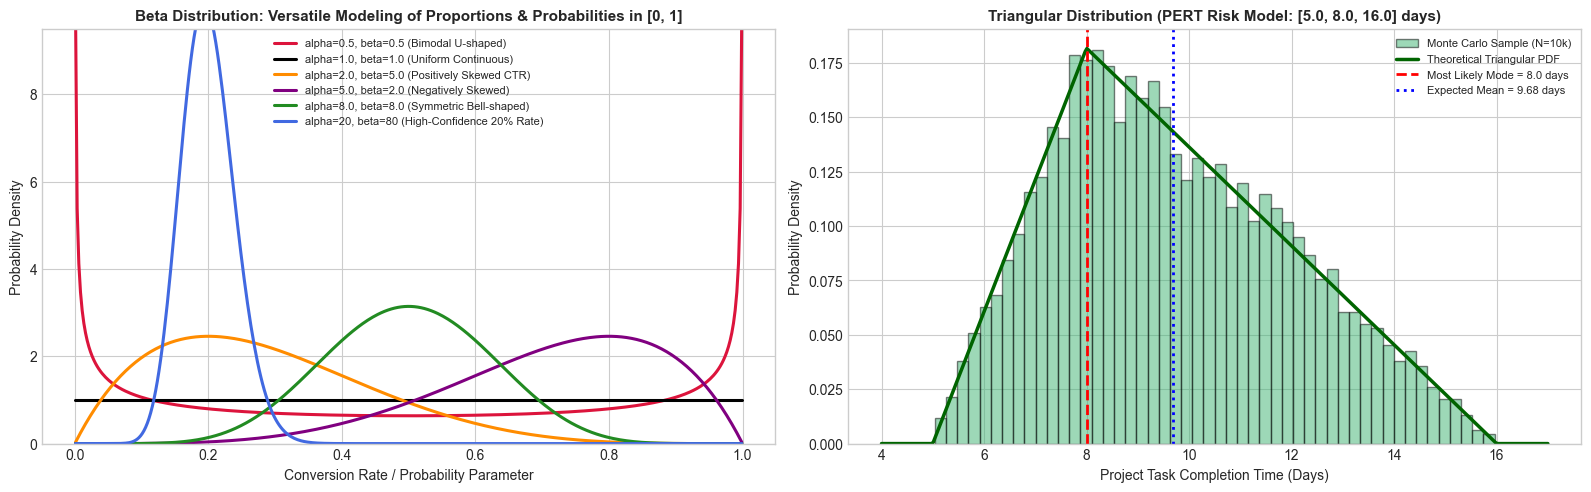

In [9]:
# ==============================================================================
# SECTION 4 CODE: BETA DISTRIBUTION SHAPE GALLERY & TRIANGULAR SIMULATION
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: The Beta Distribution Shape Chameleon
x_beta = np.linspace(0.001, 0.999, 400)
beta_cases = [
    (0.5, 0.5, 'alpha=0.5, beta=0.5 (Bimodal U-shaped)', 'crimson'),
    (1.0, 1.0, 'alpha=1.0, beta=1.0 (Uniform Continuous)', 'black'),
    (2.0, 5.0, 'alpha=2.0, beta=5.0 (Positively Skewed CTR)', 'darkorange'),
    (5.0, 2.0, 'alpha=5.0, beta=2.0 (Negatively Skewed)', 'purple'),
    (8.0, 8.0, 'alpha=8.0, beta=8.0 (Symmetric Bell-shaped)', 'forestgreen'),
    (20.0, 80.0, 'alpha=20, beta=80 (High-Confidence 20% Rate)', 'royalblue')
]

for a_val, b_val, lbl, col in beta_cases:
    axes[0].plot(x_beta, stats.beta.pdf(x_beta, a_val, b_val), color=col, lw=2.2, label=lbl)

axes[0].set_ylim(0, 9.5)
axes[0].set_title('Beta Distribution: Versatile Modeling of Proportions & Probabilities in [0, 1]', fontweight='bold')
axes[0].set_xlabel('Conversion Rate / Probability Parameter'); axes[0].set_ylabel('Probability Density')
axes[0].legend(fontsize=8, loc='upper center')

# Subplot 2: Triangular Distribution (Project Duration Simulation: a=5 days, c=8 days, b=16 days)
a_tri, c_tri, b_tri = 5.0, 8.0, 16.0
sample_tri = rng.triangular(left=a_tri, mode=c_tri, right=b_tri, size=10000)
x_tri = np.linspace(a_tri - 1, b_tri + 1, 400)
# SciPy triangular parametrization: loc = a, scale = b - a, c = (mode - a) / (b - a)
c_scaled = (c_tri - a_tri) / (b_tri - a_tri)
pdf_tri = stats.triang.pdf(x_tri, c=c_scaled, loc=a_tri, scale=b_tri - a_tri)

axes[1].hist(sample_tri, bins=50, density=True, color='mediumseagreen', alpha=0.5, edgecolor='black', label='Monte Carlo Sample (N=10k)')
axes[1].plot(x_tri, pdf_tri, color='darkgreen', lw=2.5, label='Theoretical Triangular PDF')
axes[1].axvline(c_tri, color='red', linestyle='--', lw=2.0, label=f'Most Likely Mode = {c_tri} days')
axes[1].axvline(np.mean(sample_tri), color='blue', linestyle=':', lw=2.0, label=f'Expected Mean = {np.mean(sample_tri):.2f} days')
axes[1].set_title(f'Triangular Distribution (PERT Risk Model: [{a_tri}, {c_tri}, {b_tri}] days)', fontweight='bold')
axes[1].set_xlabel('Project Task Completion Time (Days)'); axes[1].set_ylabel('Probability Density')
axes[1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


## 5. Heavy-Tailed & Specialized Symmetric Distributions

### 5.1 Laplace Distribution (Double Exponential): $\text{Laplace}(\mu, b)$
- Formed by joining two back-to-back exponential distributions at $\mu$.
- Features a sharp, non-differentiable central peak (cusp) and exponential tails ($e^{-|x|/b}$).
- **The AI Connection:** Placing a Laplace prior on linear regression coefficients corresponds mathematically to **L1 Regularization (Lasso Regression)**, driving sparse feature weights strictly to zero!

### 5.2 Cauchy Distribution (Lorentzian): $\text{Cauchy}(x_0, \gamma)$
- Arises as the ratio of two independent standard normal variables: $Z_1 / Z_2$.
- **The Pathological Case:** Has **infinite variance and an undefined mean**. The Law of Large Numbers and Central Limit Theorem fail completely for Cauchy variables!

### 5.3 Logistic Distribution: $\text{Logistic}(\mu, s)$
- Similar shape to the Gaussian but with heavier tails (kurtosis = 1.2).
- Its Cumulative Distribution Function (CDF) is the mathematical **Sigmoid Function**:
  $$F(x) = \frac{1}{1 + e^{-(x - \mu)/s}}$$
- Serves as the core link function in **Logistic Regression** and artificial neural network activations.


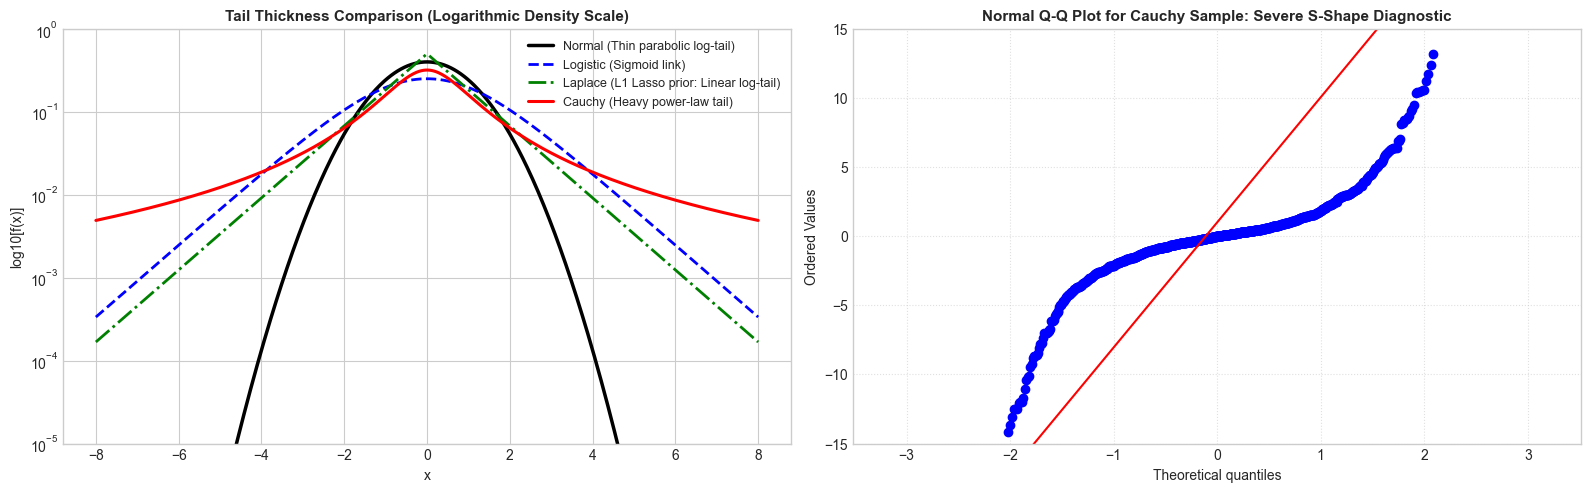

In [11]:
# ==============================================================================
# SECTION 5 CODE: TAIL THICKNESS ON SEMI-LOG SCALE & Q-Q DIAGNOSTICS
# ==============================================================================
x_tail = np.linspace(-8.0, 8.0, 600)

pdf_norm_tail = stats.norm.pdf(x_tail, 0, 1)
pdf_laplace_tail = stats.laplace.pdf(x_tail, 0, 1)
pdf_logistic_tail = stats.logistic.pdf(x_tail, 0, 1)
pdf_cauchy_tail = stats.cauchy.pdf(x_tail, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Tail Comparison on Logarithmic Density Scale (Reveals tail thickness)
axes[0].plot(x_tail, pdf_norm_tail, 'k-', lw=2.5, label='Normal (Thin parabolic log-tail)')
axes[0].plot(x_tail, pdf_logistic_tail, 'b--', lw=2.0, label='Logistic (Sigmoid link)')
axes[0].plot(x_tail, pdf_laplace_tail, 'g-.', lw=2.0, label='Laplace (L1 Lasso prior: Linear log-tail)')
axes[0].plot(x_tail, pdf_cauchy_tail, 'r-', lw=2.2, label='Cauchy (Heavy power-law tail)')
axes[0].set_yscale('log')
axes[0].set_ylim(1e-5, 1.0)
axes[0].set_title('Tail Thickness Comparison (Logarithmic Density Scale)', fontweight='bold')
axes[0].set_xlabel('x'); axes[0].set_ylabel('log10[f(x)]')
axes[0].legend(fontsize=9, loc='upper right')

# Subplot 2: Q-Q Plot against Normal Reference (Revealing Heavy Tails)
sample_cauchy_test = stats.cauchy.rvs(loc=0, scale=1, size=1000, random_state=42)
stats.probplot(sample_cauchy_test, dist="norm", plot=axes[1])
axes[1].set_title('Normal Q-Q Plot for Cauchy Sample: Severe S-Shape Diagnostic', fontweight='bold')
axes[1].set_ylim(-15, 15)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## 6. Practical Statistical Engineering: Distribution Fitting & K-S Testing

### How do Data Scientists select the correct continuous distribution for empirical data?

1. **Parametric Fitting via Maximum Likelihood Estimation (MLE):**
   SciPy's `stats.<dist>.fit(data)` optimizes distribution parameters to maximize the joint likelihood of observed samples.
2. **The Kolmogorov-Smirnov (K-S) Goodness-of-Fit Test (`stats.kstest`):**
   - Calculates the maximum vertical discrepancy $D$ between the **Empirical CDF** $F_n(x)$ and candidate **Theoretical CDF** $F(x)$:
     $$D = \sup_{x} |F_n(x) - F(x)|$$
   - **Hypothesis Decision Rule:**
     - $H_0$: The empirical data is generated by candidate distribution $F(x)$.
     - If $p\text{-value} > 0.05$: **Fail to reject $H_0$** (Good fit, strong candidate model).
     - If $p\text{-value} \le 0.05$: **Reject $H_0$** (Data does not originate from this distribution).


         KOLMOGOROV-SMIRNOV GOODNESS-OF-FIT BENCHMARK FOR EMPIRICAL DATA        
Candidate Model  K-S Statistic (D)    p-value      Verdict (alpha=0.05)
          Gamma            0.01349    0.94416 Accept H0 (Excellent Fit)
     Log-Normal            0.02212    0.44869 Accept H0 (Excellent Fit)
         Normal            0.08297    0.00000      Reject H0 (Poor Fit)
    Exponential            0.18429    0.00000      Reject H0 (Poor Fit)

Optimal Model Selected by Minimum K-S Discrepancy: >>> Gamma <<<
Fitted Gamma Parameters: Shape = 2.897 (True: 3.0), Scale = 2.621 (True: 2.5)


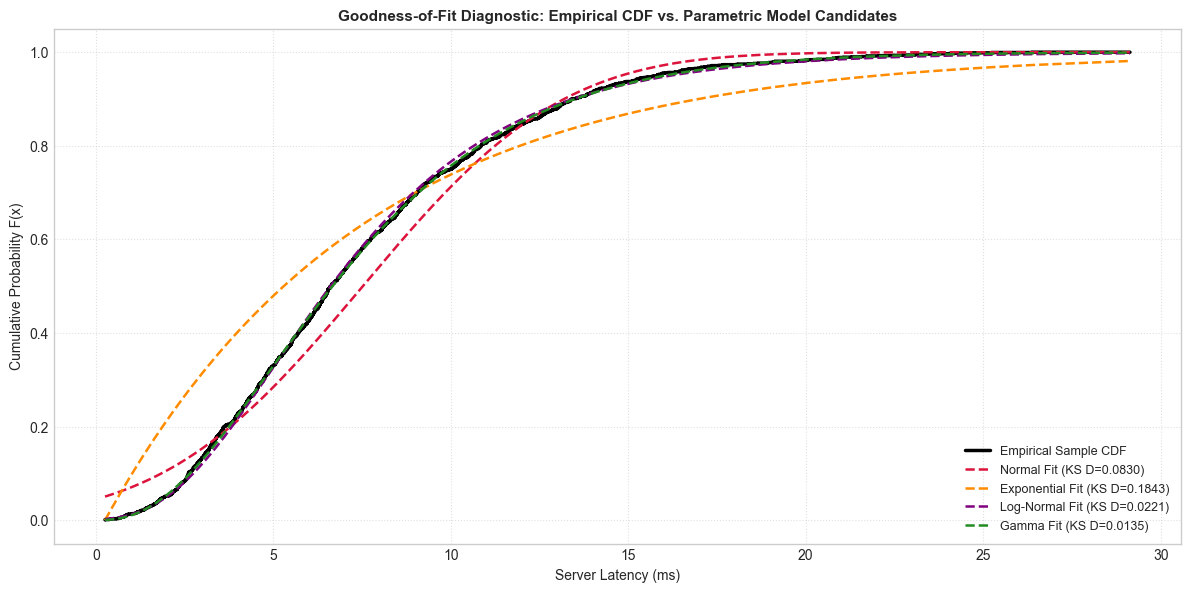

In [13]:
# ==============================================================================
# SECTION 6 CODE: EMPIRICAL DISTRIBUTION FITTING & K-S BENCHMARK
# ==============================================================================
# 1. Generate an unknown empirical dataset (Synthetic server response latency)
# True process: Gamma(shape=3.0, scale=2.5)
true_shape, true_scale = 3.0, 2.5
empirical_latency = rng.gamma(shape=true_shape, scale=true_scale, size=1500)

# 2. Fit 4 Candidate Continuous Models via MLE
candidates = {
    'Normal': stats.norm,
    'Exponential': stats.expon,
    'Log-Normal': stats.lognorm,
    'Gamma': stats.gamma
}

ks_results = []
fitted_params = {}

for name, dist_obj in candidates.items():
    # Fit parameters via MLE
    params = dist_obj.fit(empirical_latency)
    fitted_params[name] = params
    
    # Run Kolmogorov-Smirnov Test
    ks_stat, p_val = stats.kstest(empirical_latency, dist_obj.name, args=params)
    
    ks_results.append({
        'Candidate Model': name,
        'K-S Statistic (D)': ks_stat,
        'p-value': p_val,
        'Verdict (alpha=0.05)': 'Accept H0 (Excellent Fit)' if p_val > 0.05 else 'Reject H0 (Poor Fit)'
    })

ks_df = pd.DataFrame(ks_results).sort_values('K-S Statistic (D)')

print("=" * 85)
print("         KOLMOGOROV-SMIRNOV GOODNESS-OF-FIT BENCHMARK FOR EMPIRICAL DATA        ")
print("=" * 85)
print(ks_df.to_string(index=False, float_format=lambda x: f"{x:10.5f}"))
print("=" * 85)
best_model = ks_df.iloc[0]['Candidate Model']
print(f"\nOptimal Model Selected by Minimum K-S Discrepancy: >>> {best_model} <<<")
print(f"Fitted Gamma Parameters: Shape = {fitted_params['Gamma'][0]:.3f} (True: {true_shape}), Scale = {fitted_params['Gamma'][2]:.3f} (True: {true_scale})")

# 3. Visual Diagnostic: Empirical CDF vs. Candidate CDFs
x_eval_ks = np.sort(empirical_latency)
empirical_cdf = np.arange(1, len(x_eval_ks) + 1) / len(x_eval_ks)

plt.figure(figsize=(12, 6))
plt.step(x_eval_ks, empirical_cdf, color='black', lw=2.5, label='Empirical Sample CDF')

colors_fit = {'Normal': 'crimson', 'Exponential': 'darkorange', 'Log-Normal': 'purple', 'Gamma': 'forestgreen'}
for name, dist_obj in candidates.items():
    cdf_fit = dist_obj.cdf(x_eval_ks, *fitted_params[name])
    plt.plot(x_eval_ks, cdf_fit, color=colors_fit[name], lw=1.8, linestyle='--',
             label=f"{name} Fit (KS D={ks_df.loc[ks_df['Candidate Model']==name, 'K-S Statistic (D)'].values[0]:.4f})")

plt.title('Goodness-of-Fit Diagnostic: Empirical CDF vs. Parametric Model Candidates', fontweight='bold')
plt.xlabel('Server Latency (ms)')
plt.ylabel('Cumulative Probability F(x)')
plt.legend(fontsize=9, loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## 7. Master Summary: Continuous Probability Distributions Cheat Sheet

| Distribution | NumPy Call (`rng`) | SciPy Distribution | Primary Real-World Application |
| :--- | :--- | :--- | :--- |
| **Normal** | `rng.normal(loc, scale, size)` | `stats.norm(loc, scale)` | Baseline measurement errors, CLT convergence, Linear Regression errors. |
| **Uniform** | `rng.uniform(low, high, size)` | `stats.uniform(loc, scale)` | Random search hyperparameter grids, non-informative prior baseline. |
| **Exponential** | `rng.exponential(scale, size)` | `stats.expon(scale)` | Memoryless inter-arrival times, customer service durations. |
| **Gamma** | `rng.gamma(shape, scale, size)` | `stats.gamma(a, scale)` | Multi-stage queue delays, rainfall depth, Poisson rate prior. |
| **Weibull** | `rng.weibull(a, size) * scale` | `stats.weibull_min(c, scale)` | Industrial reliability, component aging and fatigue, wind speeds. |
| **Log-Normal** | `rng.lognormal(mean, sigma, size)` | `stats.lognorm(s, scale)` | Financial asset prices, household income distribution, file downloads. |
| **Pareto** | `(rng.pareto(a, size) + 1) * xm` | `stats.pareto(b, scale)` | 80/20 power law, extreme wealth inequality, internet packet bursts. |
| **Student's t**| `rng.standard_t(df, size)` | `stats.t(df)` | Small-sample inference when $\sigma$ is unknown, robust regression. |
| **Chi-Square** | `rng.chisquare(df, size)` | `stats.chi2(df)` | Sample variance inference, Goodness-of-Fit tests, feature selection. |
| **F-Distribution**| `rng.f(dfnum, dfden, size)` | `stats.f(dfn, dfd)` | ANOVA multi-group variance ratio, regression overall significance. |
| **Beta** | `rng.beta(a, b, size)` | `stats.beta(a, b)` | Proportions, conversion rates, click-through rates (CTR) in $[0, 1]$. |
| **Triangular**| `rng.triangular(left, mode, right, size)`| `stats.triang(c, loc, scale)`| Project risk simulation (PERT/CPM: Best-case, Most Likely, Worst-case). |
| **Laplace** | `rng.laplace(loc, scale, size)` | `stats.laplace(loc, scale)` | L1 Lasso regularization prior, differential privacy noise. |
| **Cauchy** | `stats.cauchy.rvs(loc, scale, size)` | `stats.cauchy(loc, scale)` | Undefined variance / mean, stress-testing algorithmic stability. |
| **Logistic** | `rng.logistic(loc, scale, size)` | `stats.logistic(loc, scale)` | Sigmoid link function for Logistic Regression and Neural Networks. |